<a href="https://colab.research.google.com/github/kaiogva/BIGDATA-PYTHON/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Análise de Segurança Pública - Saquarema

[1/5] Lendo arquivo...
Colunas encontradas: ['data', 'bairro', 'tipo_crime', 'ocorrencias_registradas', 'cameras_proximas', 'tempo_resposta_minutos', 'fonte_registro']
Total de registros: 50,000

[2/5] Limpando os dados...
Período dos dados: 2022-01-01 a 2025-04-15
Tipos de crime: ['trafico_de_drogas' 'vandalismo' 'roubo' 'perturbacao_da_ordem' 'furto'
 'ameaca' 'assalto_a_comercio' 'violencia_domestica' 'assalto_a_pedestre'
 'dano_ao_patrimonio']
Bairros: ['Jaconé' 'Boqueirao' 'Sampaio Correia' 'Vilatur' 'Barra Nova'
 "Rio d'Areia" 'Centro' 'Itauna' 'Bacaxa' 'Porto da Roça' 'Raia']

[3/5] Processando dados de roubo...

[4/5] Treinando o modelo de IA...
Precisão do modelo (R²): 0.052
→ Modelo FRACO: os dados têm muito variação irregular

[5/5] Gerando visualizações...


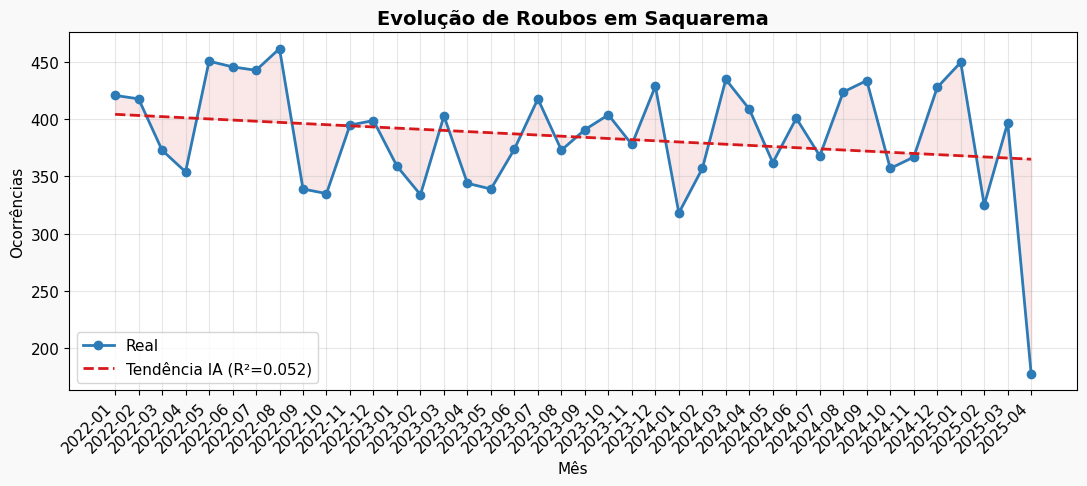

✓ Gráfico 1 salvo: grafico1_evolucao_roubos.png


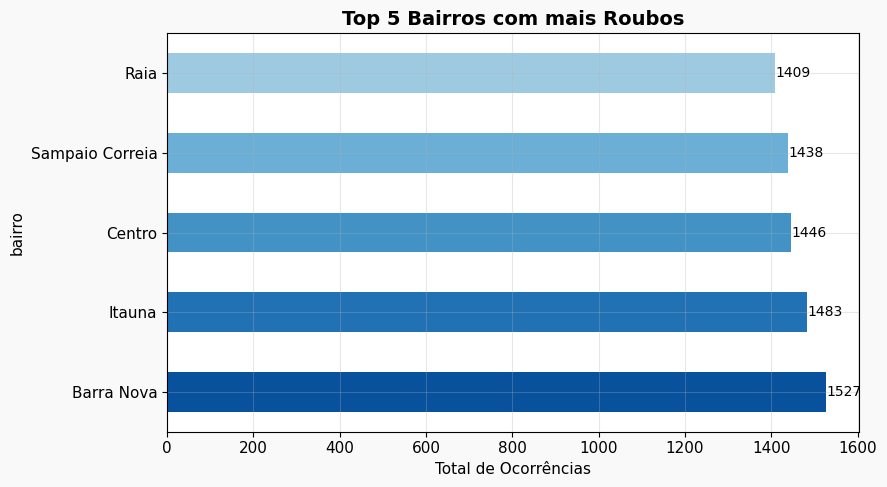

✓ Gráfico 2 salvo: grafico2_top_bairros.png


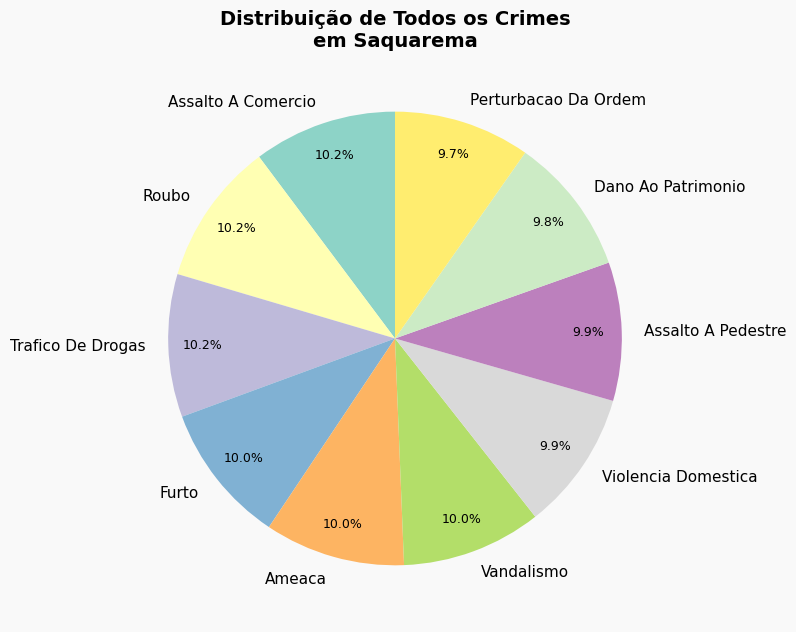

✓ Gráfico 3 (NOVO) salvo: grafico3_distribuicao_crimes.png
  → Mostra TODOS os tipos de crime, não só roubo


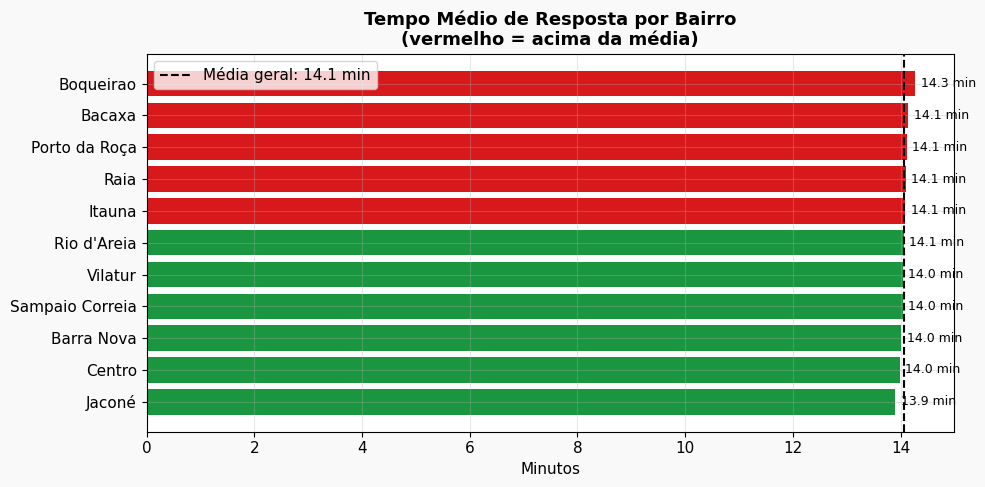

✓ Gráfico 5 (NOVO) salvo: grafico5_tempo_resposta.png
  → Quais bairros esperam mais tempo pelo atendimento?

  RESUMO DA ANÁLISE
Total de registros analisados : 50,000
Período coberto               : 2022 a 2025
Bairro com mais roubos        : Barra Nova
Crime mais frequente          : Assalto A Comercio
Tempo médio de resposta       : 14.1 min
Precisão do modelo IA (R²)    : 0.052

Todos os gráficos foram salvos como arquivos .png!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

print("  Análise de Segurança Pública - Saquarema")


# 1. LER O EXCEL

print("\n[1/5] Lendo arquivo...")
df = pd.read_excel("seguranca_saquarema_bigdata.xlsx")

# Padronizar colunas
df.columns = df.columns.str.strip().str.lower()
print("Colunas encontradas:", df.columns.tolist())
print(f"Total de registros: {len(df):,}")

# 2. AJUSTES AUTOMÁTICOS

print("\n[2/5] Limpando os dados...")

for col in df.columns:
    if "quant" in col or "ocorrencias" in col:
        df = df.rename(columns={col: "quantidade"})

for col in df.columns:
    if "tipo" in col:
        df = df.rename(columns={col: "tipo"})

df["tipo"] = df["tipo"].astype(str).str.strip().str.lower()
df["data"] = pd.to_datetime(df["data"], errors="coerce")
df = df.dropna(subset=["data", "quantidade"])
df["mes"] = df["data"].dt.to_period("M")
df["ano"] = df["data"].dt.year

print(f"Período dos dados: {df['data'].min().date()} a {df['data'].max().date()}")
print(f"Tipos de crime: {df['tipo'].unique()}")
print(f"Bairros: {df['bairro'].unique()}")

# 3. FILTRO (ROUBOS)

print("\n[3/5] Processando dados de roubo...")
df_roubo = df[df["tipo"].str.contains("roubo", na=False)]
df_mensal = df_roubo.groupby("mes")["quantidade"].sum().reset_index()
df_mensal["tempo"] = np.arange(len(df_mensal))


# 4. INTELIGÊNCIA ARTIFICIAL

print("\n[4/5] Treinando o modelo de IA...")
if not df_mensal.empty:
    X = df_mensal[["tempo"]]
    y = df_mensal["quantidade"]

    modelo = LinearRegression()
    modelo.fit(X, y)
    df_mensal["previsao"] = modelo.predict(X)

    r2 = round(modelo.score(X, y), 3)
    print(f"Precisão do modelo (R²): {r2}")

    # Interpretação automática do R²
    if r2 >= 0.7:
        print("→ Modelo BOM: a tendência linear explica bem os dados")
    elif r2 >= 0.4:
        print("→ Modelo MODERADO: existe tendência, mas com variações")
    else:
        print("→ Modelo FRACO: os dados têm muito variação irregular")

# 5. GRÁFICOS

print("\n[5/5] Gerando visualizações...")

# --- Configuração visual geral ---
plt.rcParams.update({
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})


# GRÁFICO 1 — Evolução de Roubos + Tendência IA

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_mensal["mes"].astype(str), y,
        label="Real", marker='o', color='#2c7bb6', linewidth=2)
ax.plot(df_mensal["mes"].astype(str), df_mensal["previsao"],
        linestyle="--", label=f"Tendência IA (R²={r2})",
        color='#d7191c', linewidth=2)
ax.fill_between(range(len(df_mensal)), y, df_mensal["previsao"],
                alpha=0.1, color='#d7191c')
plt.xticks(rotation=45, ha='right')
plt.title("Evolução de Roubos em Saquarema", fontsize=14, fontweight='bold')
plt.xlabel("Mês")
plt.ylabel("Ocorrências")
plt.legend()
plt.tight_layout()
plt.savefig("grafico1_evolucao_roubos.png", dpi=150)
plt.show()
print("✓ Gráfico 1 salvo: grafico1_evolucao_roubos.png")

# GRÁFICO 2 — Top 5 Bairros com mais Roubos

fig, ax = plt.subplots(figsize=(9, 5))
top_bairros = df_roubo.groupby("bairro")["quantidade"].sum().nlargest(5)
cores = ['#08519c', '#2171b5', '#4292c6', '#6baed6', '#9ecae1']
top_bairros.plot(kind="barh", ax=ax, color=cores)
ax.set_title("Top 5 Bairros com mais Roubos", fontsize=14, fontweight='bold')
ax.set_xlabel("Total de Ocorrências")
for i, v in enumerate(top_bairros.values):
    ax.text(v + 0.5, i, str(int(v)), va='center', fontsize=10)
plt.tight_layout()
plt.savefig("grafico2_top_bairros.png", dpi=150)
plt.show()
print("✓ Gráfico 2 salvo: grafico2_top_bairros.png")

# GRÁFICO 3 (NOVO) — Distribuição de TODOS os crimes

fig, ax = plt.subplots(figsize=(8, 8))
crimes_totais = df.groupby("tipo")["quantidade"].sum().sort_values(ascending=False)
cores_pizza = plt.cm.Set3(np.linspace(0, 1, len(crimes_totais)))
wedges, texts, autotexts = ax.pie(
    crimes_totais,
    labels=[t.replace("_", " ").title() for t in crimes_totais.index],
    autopct="%1.1f%%",
    colors=cores_pizza,
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(9)
ax.set_title("Distribuição de Todos os Crimes\nem Saquarema", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("grafico3_distribuicao_crimes.png", dpi=150)
plt.show()
print("✓ Gráfico 3 (NOVO) salvo: grafico3_distribuicao_crimes.png")
print("  → Mostra TODOS os tipos de crime, não só roubo")

# GRÁFICO 4 (NOVO) — Tempo de Resposta por Bairro

if "tempo_resposta_minutos" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    resposta_bairro = df.groupby("bairro")["tempo_resposta_minutos"].mean().sort_values()
    cores_resp = ['#d7191c' if v > resposta_bairro.mean() else '#1a9641'
                  for v in resposta_bairro.values]
    bars = ax.barh(resposta_bairro.index, resposta_bairro.values, color=cores_resp)
    ax.axvline(x=resposta_bairro.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f"Média geral: {resposta_bairro.mean():.1f} min")
    ax.set_title("Tempo Médio de Resposta por Bairro\n(vermelho = acima da média)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Minutos")
    ax.legend()
    for bar, val in zip(bars, resposta_bairro.values):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f"{val:.1f} min", va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig("grafico5_tempo_resposta.png", dpi=150)
    plt.show()
    print("✓ Gráfico 5 (NOVO) salvo: grafico5_tempo_resposta.png")
    print("  → Quais bairros esperam mais tempo pelo atendimento?")

# RESUMO FINAL

crimes_totais = df.groupby("tipo")["quantidade"].sum().sort_values(ascending=False)
print("\n" + "=" * 55)
print("  RESUMO DA ANÁLISE")
print("=" * 55)
print(f"Total de registros analisados : {len(df):,}")
print(f"Período coberto               : {df['data'].min().year} a {df['data'].max().year}")
print(f"Bairro com mais roubos        : {top_bairros.index[0]}")
print(f"Crime mais frequente          : {crimes_totais.index[0].replace('_',' ').title()}")
if "tempo_resposta_minutos" in df.columns:
    print(f"Tempo médio de resposta       : {df['tempo_resposta_minutos'].mean():.1f} min")
print(f"Precisão do modelo IA (R²)    : {r2}")
print("=" * 55)
print("\nTodos os gráficos foram salvos como arquivos .png!")